In [1]:
#####let's see the output

In [1]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np
import cmcrameri.cm as cmc
import lics_tstools as lts

setting pyproj data directory


In [11]:
import os
import numpy as np
import xarray as xr
#/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/sbois_final/inter/inter2020/021D_05266_252525
# File paths
frame = ['014A_05232_242525','021D_05266_252525', '116A_05207_252525']
workdir='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/sbois_final/inter/inter2020/'
cumfile=os.path.join(workdir, f'{frame[1]}/TS_GEOCml10/cum.h5')
framefile=os.path.join(workdir,frame[1])
tide_vel_file = os.path.join(framefile, 'tide.vel')
iono_vel_file = os.path.join(framefile, 'iono.vel')
vel_file=os.path.join(framefile, frame[1]+'.vel_filt.mskd.eurasia.geo.tif')
# Load cumulative displacement dataset
cuma = xr.load_dataset(cumfile)

# Load tide.vel assuming it's a binary float32 file with the same shape as cuma.vel
shape = cuma.vel.shape
tide_data = np.fromfile(tide_vel_file, dtype='float32').reshape(shape)
iono_data = np.fromfile(iono_vel_file, dtype='float32').reshape(shape)
vlos = lts.load_tif2xr(vel_file)

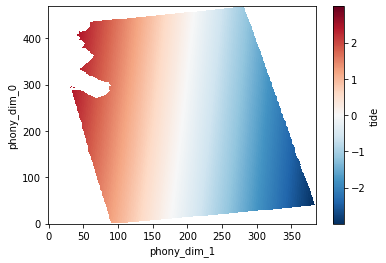

In [25]:
cuma.tide[1].plot()

In [16]:
np.shape(vlos.data)

(469, 386)

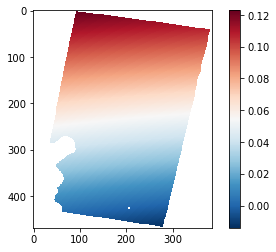

In [17]:
plt.imshow(tide_data, cmap='RdBu_r')
plt.colorbar()

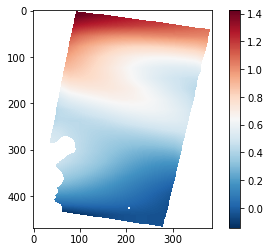

In [18]:
plt.imshow(iono_data, cmap='RdBu_r')
plt.colorbar()

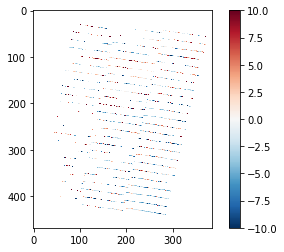

In [20]:
plt.imshow(vlos.data, interpolation='nearest', cmap='RdBu_r', vmin=-10, vmax=10)
plt.colorbar()

In [17]:
v_eurasia = lts.load_tif2xr(os.path.join(framefile, 'TS_GEOCml10/results/vel_eurasia_azi.tif'))
v_eu = v_eurasia.interp_like(vlos)

In [40]:
iono_data[200:201, 200:201]

array([[ 0.69366366]], dtype=float32)

In [52]:
import re

# Extract the string from the array
refarea = cuma.refarea.item()  # convert numpy scalar to plain string

# Split and convert to integers
refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]
# refx1, refx2, refy1, refy2 = 200, 201, 200, 201
v_eu_referenced = v_eu.copy()
tide_data_referenced = tide_data.copy()
iono_data_referenced = iono_data.copy()
vlos_referenced = vlos.copy()
v_eu_referenced.values = v_eu.values - np.nanmean(v_eu.values[refy1:refy2, refx1:refx2])
# vlos_referenced.values = vlos.values - np.nanmean(vlos.values[refy1:refy2, refx1:refx2])
tide_data_referenced = tide_data - np.nanmean(tide_data[refy1:refy2, refx1:refx2])
iono_data_referenced = iono_data - np.nanmean(iono_data[refy1:refy2, refx1:refx2])

/tmp/ipykernel_2325/3057101587.py:15: RuntimeWarning: Mean of empty slice
  tide_data_referenced = tide_data - np.nanmean(tide_data[refy1:refy2, refx1:refx2])
/tmp/ipykernel_2325/3057101587.py:16: RuntimeWarning: Mean of empty slice
  iono_data_referenced = iono_data - np.nanmean(iono_data[refy1:refy2, refx1:refx2])


In [68]:
# Read the string from the file
# Read the reference area string from the file
with open(os.path.join(framefile, 'TS_GEOCml10/info/12ref.txt'), 'r') as f:
    refarea = f.read().strip()  # e.g., '201:202/423:424'


# Split the string and convert to integers
refx1, refx2, refy1, refy2 = [int(s) for s in re.split('[:/]', refarea)]


In [69]:
print(refx1, refx2, refy1, refy2)

200 205 240 245


In [63]:
os.path.join(framefile, 'TS_GEOCml10/info/13ref.txt')

'/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic_updated/sbois_relative/inter/inter2016-2020/021D_05266_252525/TS_GEOCml10/info/13ref.txt'

In [56]:
(tide_data[refy1:refy2, refx1:refx2])

array([[ nan]], dtype=float32)

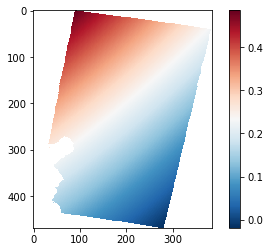

In [54]:
plt.imshow(v_eu_referenced.data, interpolation='nearest', cmap='RdBu_r')
plt.colorbar()

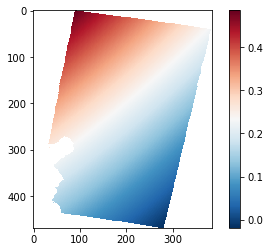

In [30]:
plt.imshow(v_eu_referenced.data, interpolation='nearest', cmap='RdBu_r')
plt.colorbar()

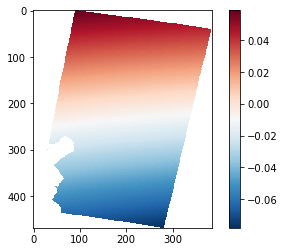

In [44]:
plt.imshow(tide_data_referenced, interpolation='nearest', cmap='RdBu_r')
plt.colorbar()

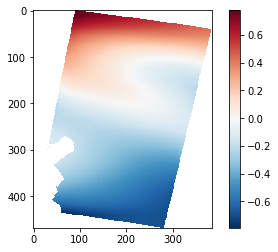

In [45]:
plt.imshow(iono_data_referenced, interpolation='nearest', cmap='RdBu_r')
plt.colorbar()

In [47]:
# Extract metadata
corner_lon, corner_lat = cuma.corner_lon.item(), cuma.corner_lat.item()
post_lon, post_lat = cuma.post_lon.item(), cuma.post_lat.item()

In [57]:
#%% Imports
import os
import re
import sys
import time
import getopt
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import pygmt
import lics_tstools as lts
from lics_unwrap import *


def create_geogrid(data_array, corner_lon, corner_lat, post_lon, post_lat):
    """Create georeferenced xarray DataArray for PyGMT plotting."""
    ny, nx = data_array.shape
    lons = corner_lon + np.arange(nx) * post_lon
    lats = corner_lat + np.arange(ny) * post_lat
    if post_lat < 0:
        lats = lats[::-1]
        data_array = data_array[::-1, :]
    return xr.DataArray(data_array, coords={"lat": lats, "lon": lons}, dims=["lat", "lon"], name="z")


tide_cum= create_geogrid(tide_data_referenced, corner_lon, corner_lat, post_lon, post_lat)


# Region
region = [corner_lon, corner_lon + shape[1] * post_lon,
          corner_lat + shape[0] * post_lat, corner_lat]

# fig = pygmt.Figure()
# pygmt.config(MAP_FRAME_PEN='0.7p,black',FONT_LABEL='12p,Helvetica', FONT_ANNOT='10p,Helvetica',MAP_FRAME_TYPE="inside",FORMAT_GEO_MAP="DD")

v = np.nanpercentile(tide_cum.data, [2, 98])
print(v)
# lim = max(abs(v[0]), abs(v[1]))
# if i == 0 or i == 5:
#     cmap_range = [-10, 10]
# else:
#     cmap_range = [-round(lim, 1), round(lim, 1)]



    
#         # Plotting loop (6 panels)
#         for i, (label, grid) in enumerate(grids.items()):
#             if i == 1:
#                 fig.shift_origin(xshift='5.3c', yshift='1.5c')
#             elif i == 2 or i == 3 or i == 4:
#                 fig.shift_origin(xshift='3.1c')
#             if i == 5:
#                 fig.shift_origin(xshift='3.3c', yshift='-1.5c')

#             v = np.nanpercentile(grid.data, [2, 98])
#             lim = max(abs(v[0]), abs(v[1]))
#             if i == 0 or i == 5:
#                 cmap_range = [-10, 10]
#             else:
#                 cmap_range = [-round(lim, 1), round(lim, 1)]

#             pygmt.makecpt(cmap="vik", series=cmap_range)
#             if i == 0 or i == 5:
#                 fig.basemap(projection="M5c", region=region, frame=True)
#             else:
#                 fig.basemap(projection="M3c", region=region, frame=True)
            
#             pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
#             fig.grdimage(grid=dem,cmap=True,region=region,shading=True,frame=False)
#             pygmt.makecpt(cmap="vik", series=cmap_range)
#             fig.grdimage(grid=grid, cmap=True, nan_transparent=True)
#             fig.coast(shorelines="black", water="skyblue")
#             pygmt.config(MAP_FRAME_TYPE="plain")
#             fig.colorbar(position="JBC+o-0c/0.2c+w1.75c/0.25c+ml+h+e", truncate=cmap_range,
#                         frame=f'a{cmap_range[1]}f{cmap_range[1]/2}', cmap=True)
            

#             fig.plot(x=[rectangle[0], rectangle[2], rectangle[2], rectangle[0], rectangle[0]],
#                 y=[rectangle[1], rectangle[1], rectangle[3], rectangle[3], rectangle[1]],
#                 pen="2p,black")
            
#             pygmt.config(MAP_FRAME_TYPE="inside")
#             if i == 0 or i == 5:
#                 fig.basemap(projection="M5c", region=region, frame=["x2f1","y2f1",'WSne'])
#             else:
#                 fig.basemap(projection="M3c", region=region, frame=["x2f1","y2f1",'wsne'])
                
#         # Save output
#         if not output_file:
#             output_file = f"{frame}.corrections_LoS.png"
            
#     else:
#         # Figure creation
#         fig = pygmt.Figure()
#         pygmt.config(MAP_FRAME_PEN='0.7p,black',FONT_LABEL='12p,Helvetica', FONT_ANNOT='10p,Helvetica',MAP_FRAME_TYPE="inside",FORMAT_GEO_MAP="DD")
        
#         # Plot rectangle (refarea in lon/lat)
#         ref_lon = corner_lon + np.array([refx1, refx2]) * post_lon
#         ref_lat = corner_lat + np.array([refy1, refy2]) * post_lat
#         rectangle = [ref_lon[0], ref_lat[0], ref_lon[1], ref_lat[1]]
        
#         # Plotting loop (5 panels)
#         for i, (label, grid) in enumerate(grids.items()):
#             if i == 1:
#                 fig.shift_origin(xshift='5.3c', yshift='1.5c')
#             elif i == 2 or i == 3:
#                 fig.shift_origin(xshift='3.1c')
#             if i == 4:
#                 fig.shift_origin(xshift='3.3c', yshift='-1.5c')

#             v = np.nanpercentile(grid.data, [2, 98])
#             lim = max(abs(v[0]), abs(v[1]))
#             if i == 0 or i == 4:
#                 cmap_range = [-10, 10]
#             else:
#                 cmap_range = [-round(lim, 1), round(lim, 1)]

#             pygmt.makecpt(cmap="vik", series=cmap_range)
#             if i == 0 or i == 4:
#                 fig.basemap(projection="M5c", region=region, frame=True)
#             else:
#                 fig.basemap(projection="M3c", region=region, frame=True)
            
#             pygmt.makecpt(cmap="gray", series=[-200, 10000, 3000], continuous=True, reverse=True)
#             fig.grdimage(grid=dem,cmap=True,region=region,shading=True,frame=False)
#             pygmt.makecpt(cmap="vik", series=cmap_range)
#             fig.grdimage(grid=grid, cmap=True, nan_transparent=True)
#             fig.coast(shorelines="black", water="skyblue")
#             pygmt.config(MAP_FRAME_TYPE="plain")
#             fig.colorbar(position="JBC+o-0c/0.2c+w1.75c/0.25c+ml+h+e", truncate=cmap_range,
#                         frame=f'a{cmap_range[1]}f{cmap_range[1]/2}', cmap=True)
            

#             fig.plot(x=[rectangle[0], rectangle[2], rectangle[2], rectangle[0], rectangle[0]],
#                 y=[rectangle[1], rectangle[1], rectangle[3], rectangle[3], rectangle[1]],
#                 pen="2p,black")
            
#             pygmt.config(MAP_FRAME_TYPE="inside")
#             if i == 0 or i == 4:
#                 fig.basemap(projection="M5c", region=region, frame=["x2f1","y2f1",'WSne'])
#             else:
#                 fig.basemap(projection="M3c", region=region, frame=["x2f1","y2f1",'wsne'])
                
#         # Save output
#         if not output_file:
#             output_file = f"{frame}.corrections_SBOI.png"
        
        
        
#     fig.savefig(output_file, dpi=900)
#     print(f"Plot saved to {output_file} in {round(time.time() - start_time, 2)} seconds.")

# if __name__ == "__main__":
#     sys.exit(main())


[ nan  nan]


/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
